In [43]:
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'serif'

from joblib import Parallel, delayed

import schwingerModel as sim

In [44]:
totalSteps = 100

a = 1
dimx = int(16*3)
dimt = int(32*3)

R = 10/(32*16) #ratio that we want to keep constant while taking continuum limit

beta = R*dimx*dimt

m = 0.2 *np.sqrt(10/beta)

In [46]:
models = []

subSteps = (np.geomspace(250,350,4)).astype(int)

models = Parallel(n_jobs=-1)(delayed(sim.schwingerModel)(metroSteps=totalSteps,beta=beta,dimx=dimx,dimt=dimt,aSpacing=a,fMass=m,cgRtol=1e-5,numSubSteps=subSteps[i],tqdmPosition=i) for i in range(len(subSteps)))

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]


  1%|          | 1/100 [00:05<08:24,  5.09s/it]

  1%|          | 1/100 [00:05<09:09,  5.55s/it]


  2%|▏         | 2/100 [00:10<08:18,  5.09s/it]

  2%|▏         | 2/100 [00:11<09:00,  5.51s/it]


  3%|▎         | 3/100 [00:15<08:22,  5.18s/it]

  3%|▎         | 3/100 [00:17<09:15,  5.73s/it]


  4%|▍         | 4/100 [00:21<08:32,  5.34s/it]

  5%|▌         | 5/100 [00:24<07:44,  4.89s/it]


  5%|▌         | 5/100 [00:26<08:32,  5.40s/it]

  6%|▌         | 6/100 [00:32<08:36,  5.49s/it]


  7%|▋         | 7/100 [00:34<07:44,  4.99s/it]

  7%|▋         | 7/100 [00:37<08:28,  5.47s/it]


  8%|▊         | 8/100 [00:39<07:41,  5.01s/it]

  9%|▉         | 9/100 [00:44<07:37,  5.02s/it]


  7%|▋         | 7/100 [00:45<10:16,  6.62s/it]

 10%|█         | 10/100 [00:49<07:29,  4.99s/it][A


  8%|▊         | 8/100 [00:52<10:03,  6.56s/it]

 11%|█         | 11/100 [00:54<07:23,  4.99s/it]

 10%|█         | 10/100

In [53]:
aFracs = []
for mod in models:
    aFrac = sim.analysis.acceptanceFraction(mod)
    aFracs.append(aFrac)
aFrac = np.array(aFrac)

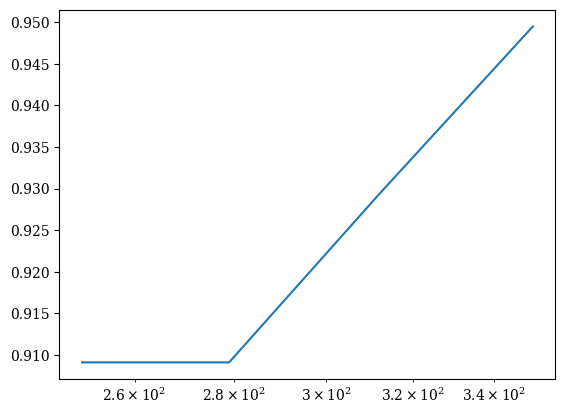

In [54]:
plt.semilogx(subSteps,aFracs)

In [59]:
subSteps[-2]

np.int64(312)

In [61]:
sim.analysis.acceptanceFraction(models[-2])

np.float64(0.9292929292929293)

In [62]:
correl = sim.distillation.correlStats(models[-1],burnIn=5,autocorrSkip=3)

configs:   0%|          | 0/32 [00:00<?, ?it/s]

In [63]:
sim.distillation.correlMassExtract(correl,fitT=[4,12],diagCov=True)

array([0.19196894, 0.00045527])